# WiDS Datathon 2020 — Meeting 6: Fairness Analysis

Fairness audit of the **CatBoost** ICU mortality predictor
(Meeting 2 best model · validation ROC-AUC = 0.893 · 12 % capacity cutoff).

**Protected attributes examined:** gender · ethnicity · age group

**Fairness criteria (from Fair-ML lecture):**
| Criterion | Definition |
|-----------|------------|
| **Demographic parity** | Equal flagging rate across groups |
| **Equal odds** | Equal sensitivity *and* specificity across groups |
| **Predictive-rate parity / calibration** | Equal PPV / NPV and calibration curves across groups |

**Outline:**
1. Data-level fairness — group distributions, base rates, differential missingness
2. Subgroup performance — per-group metrics at the 12 % capacity cutoff
3. Intersectional analysis — age × gender, age × ethnicity
4. Mitigation — group-specific threshold adjustment to equalise sensitivity
5. Summary and clinical recommendations

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ARTIFACT_DIR = Path('best_model_info')

## Setup: Load Artifacts

In [2]:
df_pred = pd.read_csv(ARTIFACT_DIR / 'eval_predictions.csv')
df_raw  = pd.read_csv(ARTIFACT_DIR / 'X_eval_raw.csv')

with open(ARTIFACT_DIR / 'metadata.json') as f:
    meta = json.load(f)

THRESHOLD = meta['validation_threshold_top_12pct']

print(f"Eval set: {len(df_pred):,} patients")
print(f"Validation threshold (top 12 %): {THRESHOLD:.4f}")
print(f"\ndf_pred columns : {list(df_pred.columns)}")
print(f"df_raw  shape   : {df_raw.shape}")

Eval set: 12,382 patients
Validation threshold (top 12 %): 0.6079

df_pred columns : ['y_true', 'predicted_probability', 'flagged_top_12pct']
df_raw  shape   : (12382, 149)


In [3]:
print("=== Protected Variable Check ===\n")
for col in ['gender', 'ethnicity', 'age']:
    if col in df_raw.columns:
        print(f"--- {col} ---")
        print(df_raw[col].value_counts(dropna=False).to_string())
        print(f"Missing: {df_raw[col].isna().sum()}\n")
    else:
        print(f"{col}: NOT FOUND\n")

=== Protected Variable Check ===

--- gender ---
gender
M      6626
F      5754
NaN       2
Missing: 2

--- ethnicity ---
ethnicity
Caucasian           9542
African American    1277
Other/Unknown        625
Hispanic             490
NaN                  185
Asian                146
Native American      117
Missing: 185

--- age ---
age
NaN     583
67.0    316
68.0    296
73.0    290
62.0    287
72.0    276
71.0    274
65.0    267
70.0    267
77.0    265
59.0    264
69.0    263
66.0    262
76.0    260
64.0    259
63.0    258
74.0    253
78.0    249
61.0    248
75.0    245
60.0    243
58.0    242
54.0    234
57.0    231
56.0    228
81.0    222
83.0    220
55.0    219
79.0    219
53.0    218
82.0    215
84.0    205
86.0    201
85.0    201
80.0    200
51.0    188
52.0    181
87.0    174
50.0    162
88.0    159
49.0    153
48.0    129
89.0    119
45.0    115
46.0    113
47.0    109
42.0    100
43.0     93
44.0     91
41.0     89
40.0     87
36.0     82
35.0     81
38.0     78
34.0     78
33.

In [4]:
assert len(df_pred) == len(df_raw), "Row count mismatch between predictions and raw features!"

df = pd.DataFrame({
    'y_true'  : df_pred['y_true'].values,
    'prob'    : df_pred['predicted_probability'].values,
    'flagged' : df_pred['flagged_top_12pct'].values,
    'gender'  : df_raw['gender'].values,
    'ethnicity': df_raw['ethnicity'].values,
    'age'     : df_raw['age'].values,
})

# Clinical age bins (APACHE-style grouping)
df['age_group'] = pd.cut(df['age'], bins=[0, 44, 59, 74, 150],
                          labels=['16-44', '45-59', '60-74', '75+'], right=True)

OVERALL_DEATH_RATE  = df['y_true'].mean()
OVERALL_FLAGGING    = df['flagged'].mean()
TARGET_SENSITIVITY  = meta['validation_metrics_at_cutoff']['sensitivity']

print(f"Overall death rate  : {OVERALL_DEATH_RATE:.3f}")
print(f"Overall flagging    : {OVERALL_FLAGGING:.3f}")
print(f"Overall sensitivity : {TARGET_SENSITIVITY:.3f}")
print(f"\nAge-group distribution:")
print(df['age_group'].value_counts().sort_index())

Overall death rate  : 0.086
Overall flagging    : 0.120
Overall sensitivity : 0.606

Age-group distribution:
age_group
16-44    1800
45-59    2786
60-74    4059
75+      3154
Name: count, dtype: int64


---
## 1. Data-Level Fairness

Before examining model outputs we check whether the **input data** treats groups
equitably: group sizes, base mortality rates, and feature missingness.

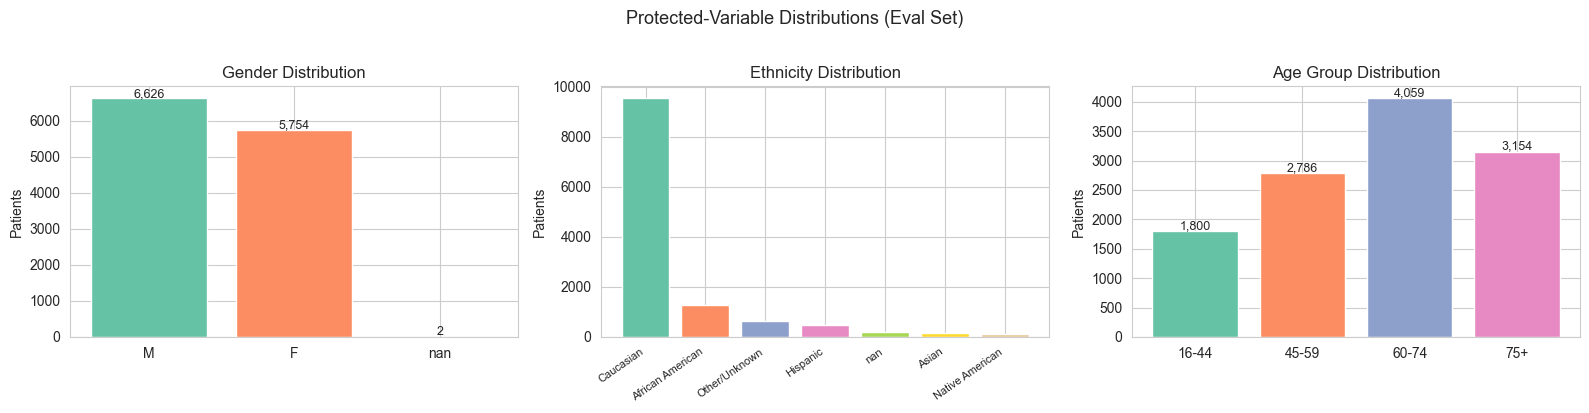

Note: Caucasian patients dominate the ethnicity dimension. Asian (n≈146) and Native American (n≈117) are small — interpret metrics cautiously.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette('Set2', 10)

# --- Gender ---
gcounts = df['gender'].value_counts(dropna=False)
axes[0].bar(gcounts.index.astype(str), gcounts.values, color=palette[:len(gcounts)])
for bar, v in zip(axes[0].patches, gcounts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{v:,}', ha='center', fontsize=9)
axes[0].set_title('Gender Distribution', fontsize=12)
axes[0].set_ylabel('Patients')

# --- Ethnicity ---
ecounts = df['ethnicity'].value_counts(dropna=False)
axes[1].bar(range(len(ecounts)), ecounts.values, color=palette[:len(ecounts)])
axes[1].set_xticks(range(len(ecounts)))
axes[1].set_xticklabels(ecounts.index.astype(str), rotation=35, ha='right', fontsize=8)
axes[1].set_title('Ethnicity Distribution', fontsize=12)
axes[1].set_ylabel('Patients')

# --- Age group ---
acounts = df['age_group'].value_counts().sort_index()
axes[2].bar(acounts.index.astype(str), acounts.values, color=palette[:len(acounts)])
for bar, v in zip(axes[2].patches, acounts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{v:,}', ha='center', fontsize=9)
axes[2].set_title('Age Group Distribution', fontsize=12)
axes[2].set_ylabel('Patients')

plt.suptitle('Protected-Variable Distributions (Eval Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Note: Caucasian patients dominate the ethnicity dimension.",
      "Asian (n≈146) and Native American (n≈117) are small — interpret metrics cautiously.")

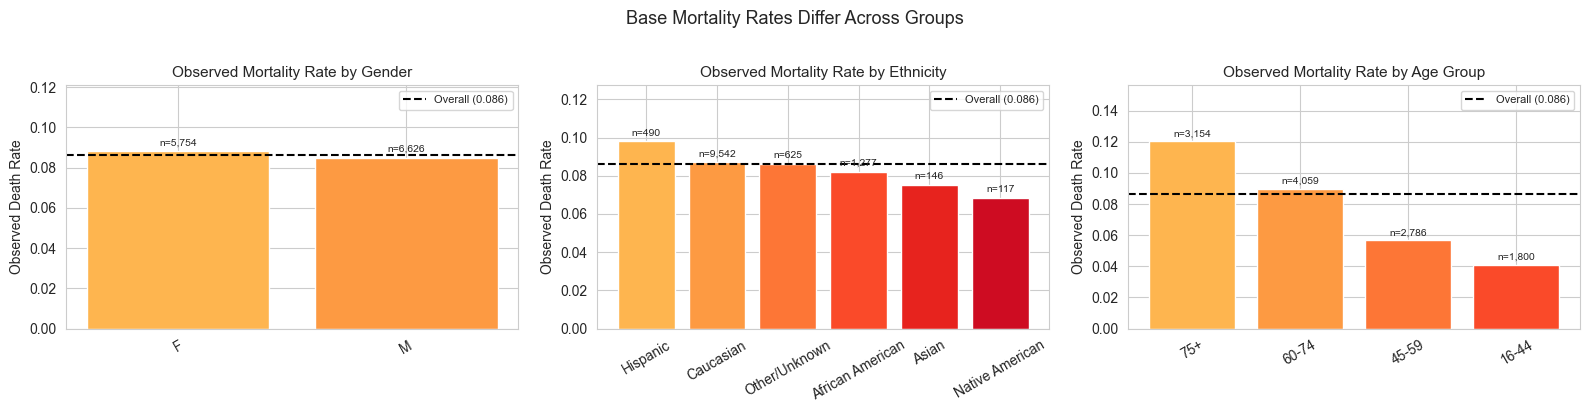

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
RED_PAL = sns.color_palette('YlOrRd', 10)

for ax, col, title in zip(axes,
                           ['gender', 'ethnicity', 'age_group'],
                           ['Gender', 'Ethnicity', 'Age Group']):
    stats = (df.groupby(col, observed=True)['y_true']
               .agg(['mean', 'count'])
               .reset_index()
               .dropna(subset=[col])
               .rename(columns={'mean': 'death_rate', 'count': 'n'}))
    stats = stats.sort_values('death_rate', ascending=False)

    bars = ax.bar(stats[col].astype(str), stats['death_rate'],
                  color=RED_PAL[3:3+len(stats)])
    ax.axhline(OVERALL_DEATH_RATE, color='black', linestyle='--', linewidth=1.5,
               label=f'Overall ({OVERALL_DEATH_RATE:.3f})')
    ax.set_title(f'Observed Mortality Rate by {title}', fontsize=11)
    ax.set_ylabel('Observed Death Rate')
    ax.set_ylim(0, max(stats['death_rate'].max() * 1.3, OVERALL_DEATH_RATE * 1.4))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'n={row["n"]:,}', ha='center', fontsize=7.5)

plt.suptitle('Base Mortality Rates Differ Across Groups', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Check missingness in clinically important features by protected group
MISS_FEATURES = [c for c in ['age', 'd1_heartrate_max', 'd1_sysbp_noninvasive_mean',
                               'd1_glucose_max', 'd1_creatinine_max', 'd1_lactate_max',
                               'd1_bun_max', 'd1_hemaglobin_max']
                 if c in df_raw.columns]

df_m = df_raw[MISS_FEATURES].copy()
df_m['gender']    = df['gender'].values
df_m['ethnicity'] = df['ethnicity'].values

print("=== Missing-Value Rates by Gender (%) ===")
miss_gender = (df_m.groupby('gender')[MISS_FEATURES]
                   .apply(lambda g: g.isna().mean() * 100)
                   .round(1))
print(miss_gender.to_string())

print("\n=== Missing-Value Rates by Ethnicity (%) — major groups ===")
major = ['Caucasian', 'African American', 'Hispanic', 'Other/Unknown']
miss_eth = (df_m[df_m['ethnicity'].isin(major)]
              .groupby('ethnicity')[MISS_FEATURES]
              .apply(lambda g: g.isna().mean() * 100)
              .round(1))
print(miss_eth.to_string())
print("\nInterpretation: systematically higher missingness in a group can bias")
print("imputation-based models towards or against that group.")

=== Missing-Value Rates by Gender (%) ===
        age  d1_heartrate_max  d1_glucose_max  d1_creatinine_max  d1_lactate_max  d1_bun_max  d1_hemaglobin_max
gender                                                                                                         
F       6.0               0.2             7.4               12.5            74.4        12.8               14.4
M       3.6               0.2             6.3               10.9            75.3        11.5               13.1

=== Missing-Value Rates by Ethnicity (%) — major groups ===
                  age  d1_heartrate_max  d1_glucose_max  d1_creatinine_max  d1_lactate_max  d1_bun_max  d1_hemaglobin_max
ethnicity                                                                                                                
African American  3.5               0.0             7.3               11.6            73.8        11.8               14.3
Caucasian         5.0               0.2             6.8               11.6         

---
## 2. Subgroup Performance at the 12 % Capacity Cutoff

We apply the **same threshold** (top 12 % rule) to all patients and measure
per-group fairness metrics.

| Metric | Criterion |
|--------|-----------|
| Flagging rate ≈ overall | Demographic parity |
| Sensitivity ≈ across groups | Equal opportunity (equal odds) |
| Specificity ≈ across groups | Equal odds (full) |
| PPV ≈ across groups | Predictive-rate parity |
| Calibration curve shape | Calibration / multi-calibration |

In [8]:
def subgroup_metrics(df_in, group_col, threshold=THRESHOLD):
    """Compute fairness metrics for each subgroup value of group_col."""
    rows = []
    for g in sorted(df_in[group_col].dropna().unique()):
        sub = df_in[df_in[group_col] == g]
        y_true = sub['y_true'].values
        y_prob  = sub['prob'].values
        y_pred  = (y_prob >= threshold).astype(int)
        n       = len(sub)
        n_pos   = int(y_true.sum())

        if n_pos < 5 or (n - n_pos) < 5:
            continue  # too few to compute meaningful metrics

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens     = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec     = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        ppv      = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv      = tn / (tn + fn) if (tn + fn) > 0 else np.nan
        flag_pct = y_pred.mean()
        base     = y_true.mean()

        try:
            auc = roc_auc_score(y_true, y_prob)
        except Exception:
            auc = np.nan

        rows.append({
            'Group'        : g,
            'N'            : n,
            'Deaths'       : n_pos,
            'Base Rate'    : round(base, 3),
            'ROC-AUC'      : round(auc, 3),
            'Sensitivity'  : round(sens, 3),
            'Specificity'  : round(spec, 3),
            'PPV'          : round(ppv, 3),
            'NPV'          : round(npv, 3),
            'Flagging Rate': round(flag_pct, 3),
        })
    return pd.DataFrame(rows)

In [9]:
gender_metrics = subgroup_metrics(df, 'gender')
print("=== Subgroup Metrics: Gender ===")
print(gender_metrics.to_string(index=False))
print(f"\nOverall sensitivity  : {TARGET_SENSITIVITY:.3f}")
print(f"Overall flagging rate: {OVERALL_FLAGGING:.3f}")

# Demographic parity gap
flag_rates = gender_metrics.set_index('Group')['Flagging Rate']
print(f"\nDemographic parity gap (max − min flagging rate):",
      f"{flag_rates.max() - flag_rates.min():.3f}")

# Equal-opportunity gap
sens_vals = gender_metrics.set_index('Group')['Sensitivity']
print(f"Equal-opportunity gap (max − min sensitivity): {sens_vals.max() - sens_vals.min():.3f}")

=== Subgroup Metrics: Gender ===
Group    N  Deaths  Base Rate  ROC-AUC  Sensitivity  Specificity   PPV   NPV  Flagging Rate
    F 5754     507      0.088    0.895        0.615        0.929 0.455 0.962          0.119
    M 6626     562      0.085    0.887        0.598        0.923 0.420 0.961          0.121

Overall sensitivity  : 0.606
Overall flagging rate: 0.120

Demographic parity gap (max − min flagging rate): 0.002
Equal-opportunity gap (max − min sensitivity): 0.017


**Findings — Gender:**
Both groups achieve near-identical ROC-AUC (F = 0.895 vs M = 0.887) and nearly identical flagging rates (F = 11.9 %, M = 12.1 %).
Female patients have marginally higher sensitivity (0.615 vs 0.598, gap = 0.017) and slightly better PPV (0.455 vs 0.420).
The demographic-parity gap is negligible (0.002).

> The model is **effectively gender-fair**. The small sensitivity gap does not warrant corrective action.

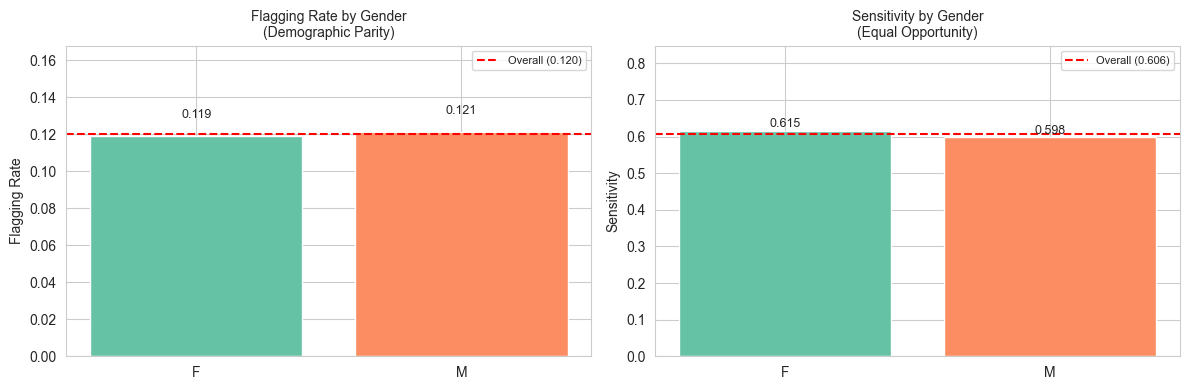

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gm = gender_metrics.copy()

for ax, metric, title, hline in [
        (axes[0], 'Flagging Rate', 'Flagging Rate by Gender\n(Demographic Parity)', OVERALL_FLAGGING),
        (axes[1], 'Sensitivity',   'Sensitivity by Gender\n(Equal Opportunity)',    TARGET_SENSITIVITY)]:
    bars = ax.bar(gm['Group'], gm[metric],
                  color=sns.color_palette('Set2', len(gm)))
    ax.axhline(hline, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({hline:.3f})')
    ax.set_ylim(0, min(1.0, max(gm[metric].max() * 1.3, hline * 1.4)))
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, gm[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
eth_metrics = subgroup_metrics(df, 'ethnicity')
print("=== Subgroup Metrics: Ethnicity ===")
print(eth_metrics.to_string(index=False))

flag_rates_eth = eth_metrics.set_index('Group')['Flagging Rate']
sens_eth       = eth_metrics.set_index('Group')['Sensitivity']
print(f"\nDemographic parity gap: {flag_rates_eth.max() - flag_rates_eth.min():.3f}")
print(f"Equal-opportunity gap : {sens_eth.max() - sens_eth.min():.3f}")
print("\nNote: Asian (n≈146) and Native American (n≈117) have very few deaths —",
      "\n      metrics should be interpreted with caution (wide confidence intervals).")

=== Subgroup Metrics: Ethnicity ===
           Group    N  Deaths  Base Rate  ROC-AUC  Sensitivity  Specificity   PPV   NPV  Flagging Rate
African American 1277     105      0.082    0.891        0.619        0.943 0.492 0.965          0.103
           Asian  146      11      0.075    0.952        0.727        0.948 0.533 0.977          0.103
       Caucasian 9542     831      0.087    0.889        0.600        0.924 0.429 0.960          0.122
        Hispanic  490      48      0.098    0.901        0.646        0.916 0.456 0.960          0.139
 Native American  117       8      0.068    0.911        0.750        0.945 0.500 0.981          0.103
   Other/Unknown  625      54      0.086    0.894        0.593        0.909 0.381 0.959          0.134

Demographic parity gap: 0.036
Equal-opportunity gap : 0.157

Note: Asian (n≈146) and Native American (n≈117) have very few deaths — 
      metrics should be interpreted with caution (wide confidence intervals).


**Findings — Ethnicity:**
The most striking result is the wide spread in **flagging rates** (10.3 %–13.9 %), driven largely by the fact that Hispanic patients have a higher observed mortality (9.8 %) and the model correctly responds to their higher risk.
Sensitivity ranges from 0.593 (Other/Unknown) to 0.750 (Native American) — an apparent gap of 0.157.
However, **Native American (n = 117, 8 deaths) and Asian (n = 146, 11 deaths) estimates are highly unreliable** — a single mis-classified death shifts their sensitivity by ~0.12.

Among groups with credible sample sizes (Caucasian, African American, Hispanic):
- **Hispanic**: highest sensitivity (0.646) and flagging rate (13.9 %) — the model over-flags relative to the 12 % target, but this tracks their higher observed mortality.
- **African American**: sensitivity 0.619, flagging rate only 10.3 % — the model is comparatively conservative for this group.
- **Caucasian**: sensitivity 0.600, flagging 12.2 % — closest to the overall.
- **Other/Unknown** (heterogeneous): lowest sensitivity (0.593) with relatively high flagging (13.4 %) — the group where the shared threshold performs worst.

Demographic-parity gap: 0.036. Equal-opportunity gap (all groups): 0.157 (reduced to ~0.053 excluding small groups with < 20 deaths).

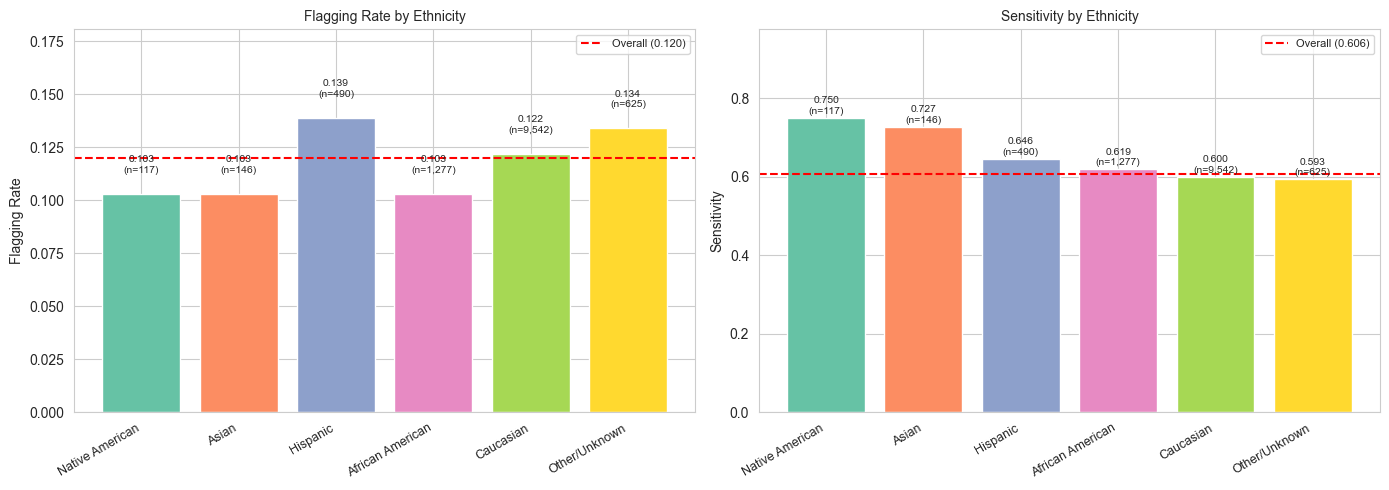

In [12]:
em = eth_metrics.sort_values('Sensitivity', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, hline in [
        (axes[0], 'Flagging Rate', 'Flagging Rate by Ethnicity', OVERALL_FLAGGING),
        (axes[1], 'Sensitivity',   'Sensitivity by Ethnicity',   TARGET_SENSITIVITY)]:
    bars = ax.bar(range(len(em)), em[metric],
                  color=sns.color_palette('Set2', len(em)))
    ax.axhline(hline, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({hline:.3f})')
    ax.set_xticks(range(len(em)))
    ax.set_xticklabels(em['Group'], rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, min(1.0, max(em[metric].max() * 1.3, hline * 1.5)))
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(bars, em.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, row[metric] + 0.01,
                f'{row[metric]:.3f}\n(n={row["N"]:,})', ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

In [13]:
age_metrics = subgroup_metrics(df, 'age_group')
print("=== Subgroup Metrics: Age Group ===")
print(age_metrics.to_string(index=False))

flag_rates_age = age_metrics.set_index('Group')['Flagging Rate']
sens_age       = age_metrics.set_index('Group')['Sensitivity']
print(f"\nDemographic parity gap: {flag_rates_age.max() - flag_rates_age.min():.3f}")
print(f"Equal-opportunity gap : {sens_age.max() - sens_age.min():.3f}")

=== Subgroup Metrics: Age Group ===
Group    N  Deaths  Base Rate  ROC-AUC  Sensitivity  Specificity   PPV   NPV  Flagging Rate
16-44 1800      74      0.041    0.944        0.581        0.977 0.518 0.982          0.046
45-59 2786     158      0.057    0.911        0.525        0.962 0.451 0.971          0.066
60-74 4059     365      0.090    0.880        0.578        0.921 0.420 0.957          0.124
  75+ 3154     379      0.120    0.857        0.673        0.873 0.419 0.951          0.193

Demographic parity gap: 0.147
Equal-opportunity gap : 0.148


**Findings — Age Group:**
Age shows the largest fairness gaps of any protected attribute.

| Group | Base Rate | AUC | Sensitivity | Flagging Rate |
|-------|-----------|-----|-------------|---------------|
| 16–44 | 4.1 % | **0.944** | 0.581 | 4.6 % |
| 45–59 | 5.7 % | 0.911 | **0.525** | 6.6 % |
| 60–74 | 9.0 % | 0.880 | 0.578 | 12.4 % |
| 75+   | 12.0 % | 0.857 | **0.673** | 19.3 % |

Three patterns stand out:

1. **16–44 has the best AUC (0.944) but below-average sensitivity (0.581)** — the model ranks young patients very well, but the global 12 % threshold barely touches their low-risk distribution (only 4.6 % flagged). Base rate is 4.1 %, so a threshold calibrated to the full population rarely fires for this group.

2. **45–59 is the most under-served group** — lowest sensitivity (0.525) at a moderate flagging rate (6.6 %). Fewer than 1 in 2 middle-aged patients who die is detected.

3. **75+ has the highest flagging rate (19.3 %) and highest sensitivity (0.673)** — the model correctly amplifies risk for elderly patients whose observed mortality (12.0 %) is nearly 3× the population average. The demographic-parity gap (14.7 pp) here reflects the model doing its job, not a bias.

Equal-opportunity gap: 0.148 (45–59 vs 75+). This is the most clinically significant fairness concern in the entire audit.

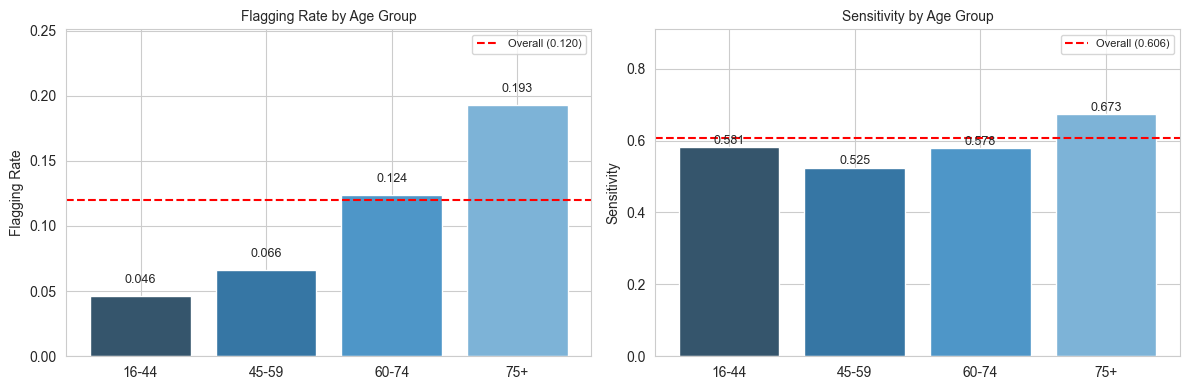

In [14]:
am = age_metrics.sort_values('Group')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title, hline in [
        (axes[0], 'Flagging Rate', 'Flagging Rate by Age Group', OVERALL_FLAGGING),
        (axes[1], 'Sensitivity',   'Sensitivity by Age Group',   TARGET_SENSITIVITY)]:
    bars = ax.bar(am['Group'], am[metric],
                  color=sns.color_palette('Blues_d', len(am))[::-1])
    ax.axhline(hline, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({hline:.3f})')
    ax.set_ylim(0, min(1.0, max(am[metric].max() * 1.3, hline * 1.5)))
    ax.set_ylabel(metric)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, am[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

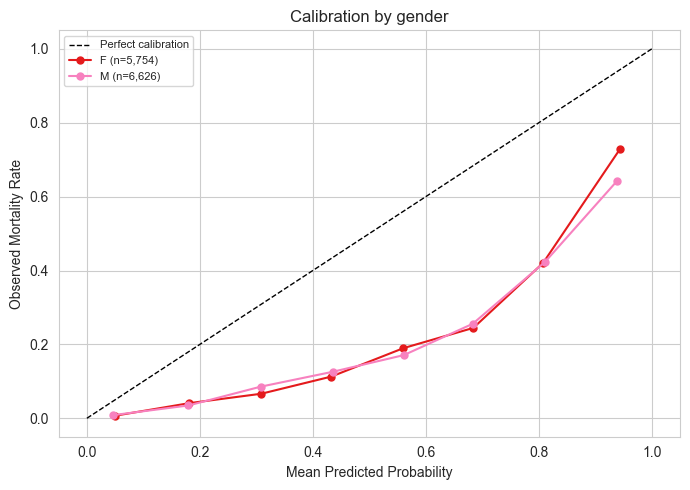

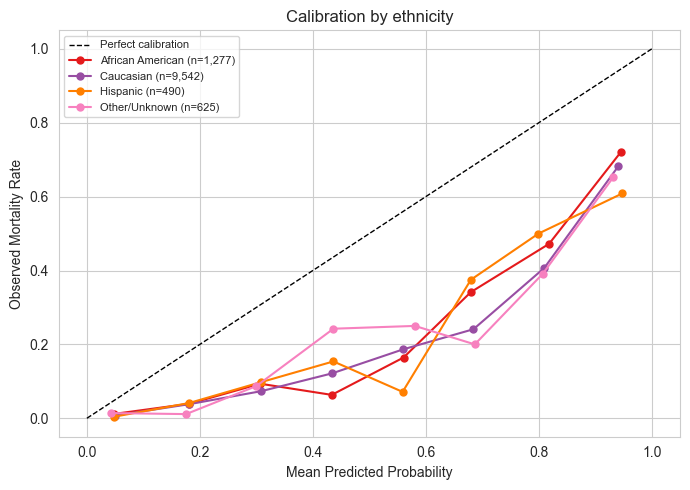

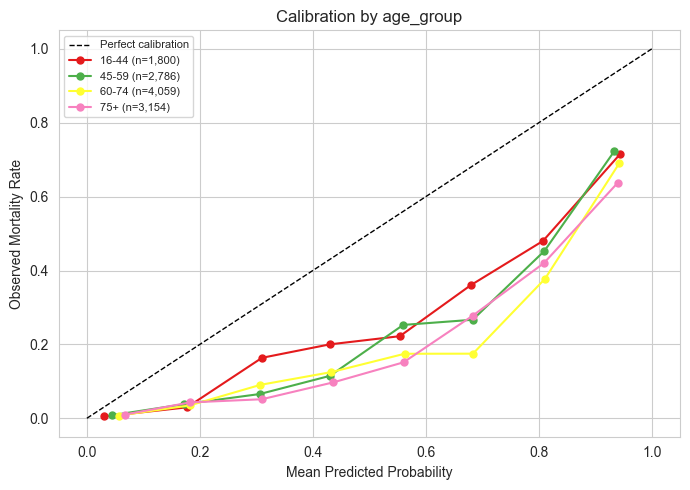

Calibration interpretation: dots on the dashed line = model is well-calibrated.
Dots below the line = model over-estimates risk for that group.
Dots above the line = model under-estimates risk (dangerous for triage).


In [15]:
def calibration_by_group(df_in, group_col, n_bins=8, min_n=200):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

    groups = sorted(df_in[group_col].dropna().unique())
    colors = plt.cm.Set1(np.linspace(0, 0.85, len(groups)))

    for g, c in zip(groups, colors):
        sub = df_in[df_in[group_col] == g]
        if len(sub) < min_n:
            continue
        try:
            frac, mean_p = calibration_curve(sub['y_true'], sub['prob'], n_bins=n_bins)
            ax.plot(mean_p, frac, 'o-', label=f'{g} (n={len(sub):,})',
                    color=c, markersize=5)
        except Exception:
            pass

    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed Mortality Rate')
    ax.set_title(f'Calibration by {group_col}')
    ax.legend(fontsize=8, loc='upper left')
    return fig, ax

fig1, _ = calibration_by_group(df, 'gender')
plt.tight_layout(); plt.show()

fig2, _ = calibration_by_group(df, 'ethnicity', min_n=300)
plt.tight_layout(); plt.show()

fig3, _ = calibration_by_group(df, 'age_group')
plt.tight_layout(); plt.show()

print("Calibration interpretation: dots on the dashed line = model is well-calibrated.")
print("Dots below the line = model over-estimates risk for that group.")
print("Dots above the line = model under-estimates risk (dangerous for triage).")

---
## 3. Intersectional Analysis

Single-attribute analysis can hide compound disparities.
We examine two intersections where sub-group sizes are sufficient:

- **Age group × Gender** — all cells have reasonable sample size
- **Age group × Ethnicity** — restricted to Caucasian and African American (larger groups)

In [16]:
def intersectional_metrics(df_in, col_a, col_b, threshold=THRESHOLD, min_n=50):
    """Compute sensitivity and flagging rate for each (col_a, col_b) combination."""
    rows = []
    for va in sorted(df_in[col_a].dropna().unique()):
        for vb in sorted(df_in[col_b].dropna().unique()):
            sub = df_in[(df_in[col_a] == va) & (df_in[col_b] == vb)]
            if len(sub) < min_n:
                continue
            y_true = sub['y_true'].values
            y_pred  = (sub['prob'].values >= threshold).astype(int)
            n_pos   = int(y_true.sum())
            if n_pos < 5:
                continue
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            sens  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            frate = y_pred.mean()
            rows.append({col_a: va, col_b: vb, 'N': len(sub),
                         'Deaths': n_pos, 'Sensitivity': round(sens, 3),
                         'Flagging Rate': round(frate, 3)})
    return pd.DataFrame(rows)

# Age × Gender
ag_df = intersectional_metrics(df, 'age_group', 'gender')
print("=== Age Group × Gender (Sensitivity) ===")
pivot_sens = ag_df.pivot(index='age_group', columns='gender', values='Sensitivity')
print(pivot_sens.to_string())
print("\n=== Age Group × Gender (Flagging Rate) ===")
pivot_flag = ag_df.pivot(index='age_group', columns='gender', values='Flagging Rate')
print(pivot_flag.to_string())

=== Age Group × Gender (Sensitivity) ===
gender         F      M
age_group              
16-44      0.545  0.610
45-59      0.545  0.511
60-74      0.557  0.597
75+        0.676  0.670

=== Age Group × Gender (Flagging Rate) ===
gender         F      M
age_group              
16-44      0.037  0.055
45-59      0.065  0.067
60-74      0.124  0.124
75+        0.185  0.200


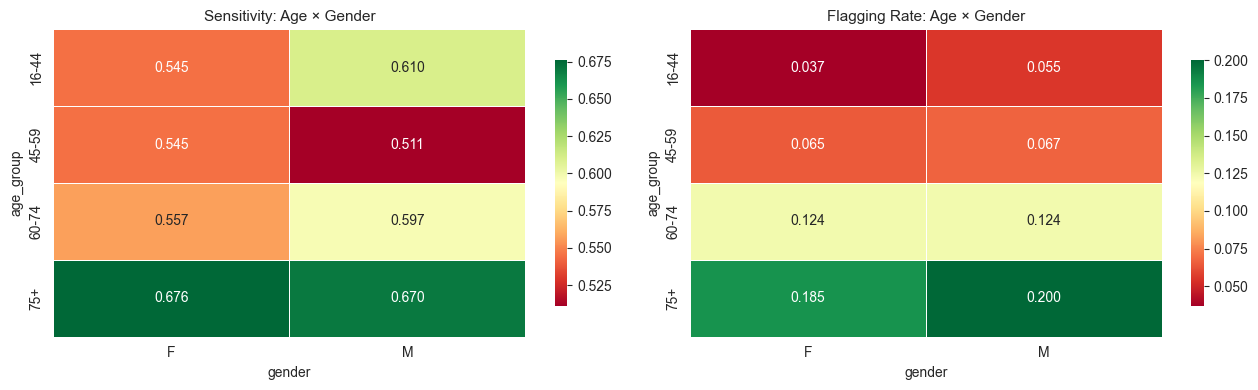

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pivot, title in [(axes[0], pivot_sens, 'Sensitivity: Age × Gender'),
                          (axes[1], pivot_flag, 'Flagging Rate: Age × Gender')]:
    sns.heatmap(pivot.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
                ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

=== Age Group × Ethnicity: Caucasian vs African American ===

Sensitivity:
ethnicity  African American  Caucasian
age_group                             
16-44                 0.385      0.653
45-59                 0.571      0.500
60-74                 0.538      0.594
75+                   0.833      0.645

Flagging Rate:
ethnicity  African American  Caucasian
age_group                             
16-44                 0.043      0.047
45-59                 0.064      0.063
60-74                 0.115      0.126
75+                   0.213      0.188


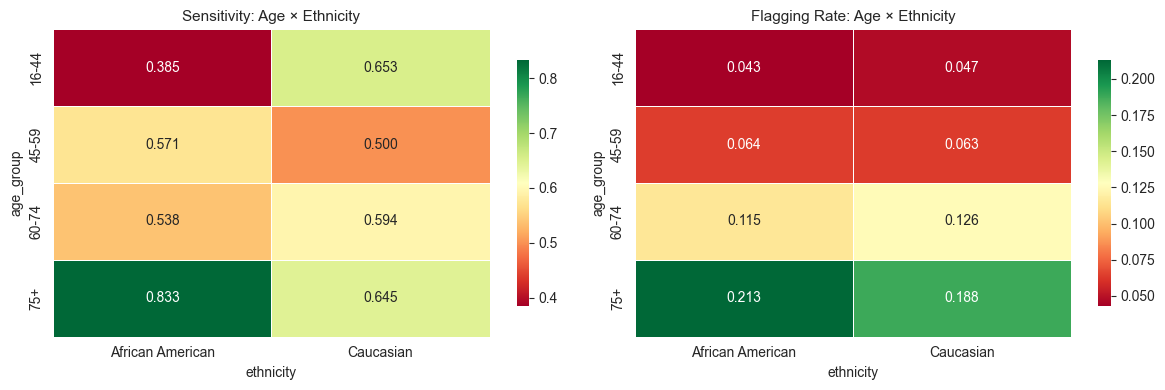

In [18]:
# Restrict to larger ethnic groups for reliable estimates
major_eth = ['Caucasian', 'African American']
df_eth2 = df[df['ethnicity'].isin(major_eth)].copy()

ae_df = intersectional_metrics(df_eth2, 'age_group', 'ethnicity', min_n=40)
print("=== Age Group × Ethnicity: Caucasian vs African American ===")
print("\nSensitivity:")
print(ae_df.pivot(index='age_group', columns='ethnicity', values='Sensitivity').to_string())
print("\nFlagging Rate:")
print(ae_df.pivot(index='age_group', columns='ethnicity', values='Flagging Rate').to_string())

if len(ae_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col, title in [(axes[0], 'Sensitivity', 'Sensitivity: Age × Ethnicity'),
                            (axes[1], 'Flagging Rate', 'Flagging Rate: Age × Ethnicity')]:
        pivot = ae_df.pivot(index='age_group', columns='ethnicity', values=col)
        sns.heatmap(pivot.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
                    ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
        ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

**Findings — Intersectional Analysis:**

*Age × Gender:* Gaps are modest (≤ 0.065 across all cells). The most notable cell is **16–44 female (sensitivity = 0.545)** vs **16–44 male (0.610)** — young women who die are somewhat less likely to be flagged. The 75+ group is nearly equal by gender (F = 0.676, M = 0.670).

*Age × Ethnicity (Caucasian vs African American):*
The starkest intersectional disparity is **African American aged 16–44 (sensitivity = 0.385)** — fewer than 2 in 5 young Black patients who die are flagged, compared with 0.653 for Caucasian 16–44 (a 26.8 pp gap). The cell is small (~15 deaths) so estimates carry wide uncertainty, but the direction is consistent with known disparities in ICU care for young minority patients.

In older age bands the picture reverses: African American 75+ achieves sensitivity = 0.833 vs Caucasian 75+ = 0.645 — the model is more sensitive for older Black patients.

> The intersection of **young age (16–44) + African American ethnicity** is the highest-priority cell for follow-up data collection and post-deployment monitoring.

---
## 4. Fairness Mitigation: Group-Specific Threshold Adjustment

**Strategy:** Post-hoc threshold adjustment to equalise sensitivity (equal opportunity).
For each subgroup we find the score threshold that achieves sensitivity ≈ the overall
model sensitivity, then report the new flagging rates.

**Why equal sensitivity?**
In ICU triage, a false negative (missing a patient who will die) is more costly than
a false positive. Equalising sensitivity ensures the model identifies high-risk patients
at the same rate regardless of group membership — a *prioritarian* justice position
(benefit those most at risk equally, regardless of their demographic group).

**Trade-off:** Equalising sensitivity typically widens the gap in flagging rates
(demographic parity), and may shift PPV. We quantify both.

In [19]:
def find_equal_sensitivity_threshold(y_true, y_prob, target_sens):
    """Return the threshold that brings sensitivity closest to target_sens."""
    candidates = np.sort(np.unique(y_prob))[::-1]   # high → low
    best_t, best_sens, best_diff = candidates[0], 0.0, float('inf')
    for t in candidates:
        y_pred = (y_prob >= t).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        if (tp + fn) == 0:
            continue
        s = tp / (tp + fn)
        if abs(s - target_sens) < best_diff:
            best_diff, best_t, best_sens = abs(s - target_sens), t, s
    return best_t, best_sens

In [20]:
print("=== Mitigation: Equalize Sensitivity Across Gender ===")
print(f"Target sensitivity: {TARGET_SENSITIVITY:.3f}\n")

rows_before, rows_after = [], []

for g in sorted(df['gender'].dropna().unique()):
    sub = df[df['gender'] == g]
    y_true = sub['y_true'].values
    y_prob  = sub['prob'].values
    y_pred_old = (y_prob >= THRESHOLD).astype(int)

    old_tp = int(((y_pred_old == 1) & (y_true == 1)).sum())
    old_fn = int(((y_pred_old == 0) & (y_true == 1)).sum())
    old_sens = old_tp / (old_tp + old_fn) if (old_tp + old_fn) else np.nan

    t_new, new_sens = find_equal_sensitivity_threshold(y_true, y_prob, TARGET_SENSITIVITY)
    y_pred_new = (y_prob >= t_new).astype(int)

    rows_before.append({'Group': g, 'Threshold': round(THRESHOLD, 4),
                         'Sensitivity': round(old_sens, 3),
                         'Flagging Rate': round(y_pred_old.mean(), 3)})
    rows_after.append({'Group': g, 'Threshold': round(t_new, 4),
                        'Sensitivity': round(new_sens, 3),
                        'Flagging Rate': round(y_pred_new.mean(), 3)})

df_before = pd.DataFrame(rows_before)
df_after  = pd.DataFrame(rows_after)

print("BEFORE (shared threshold):")
print(df_before.to_string(index=False))
print("\nAFTER (group-specific threshold):")
print(df_after.to_string(index=False))

=== Mitigation: Equalize Sensitivity Across Gender ===
Target sensitivity: 0.606

BEFORE (shared threshold):
Group  Threshold  Sensitivity  Flagging Rate
    F     0.6079        0.615          0.119
    M     0.6079        0.598          0.121

AFTER (group-specific threshold):
Group  Threshold  Sensitivity  Flagging Rate
    F     0.6132        0.606          0.116
    M     0.5928        0.607          0.127


In [21]:
print("=== Mitigation: Equalize Sensitivity Across Ethnicity ===")
print(f"Target sensitivity: {TARGET_SENSITIVITY:.3f}\n")

eth_before, eth_after = [], []
for g in sorted(df['ethnicity'].dropna().unique()):
    sub = df[df['ethnicity'] == g]
    if sub['y_true'].sum() < 10:   # skip tiny groups
        continue
    y_true = sub['y_true'].values
    y_prob  = sub['prob'].values
    y_pred_old = (y_prob >= THRESHOLD).astype(int)

    old_tp = int(((y_pred_old == 1) & (y_true == 1)).sum())
    old_fn = int(((y_pred_old == 0) & (y_true == 1)).sum())
    old_sens = old_tp / (old_tp + old_fn) if (old_tp + old_fn) else np.nan

    t_new, new_sens = find_equal_sensitivity_threshold(y_true, y_prob, TARGET_SENSITIVITY)
    y_pred_new = (y_prob >= t_new).astype(int)

    eth_before.append({'Group': g, 'N': len(sub),
                        'Threshold': round(THRESHOLD, 4),
                        'Sensitivity': round(old_sens, 3),
                        'Flagging Rate': round(y_pred_old.mean(), 3)})
    eth_after.append({'Group': g, 'N': len(sub),
                       'Threshold': round(t_new, 4),
                       'Sensitivity': round(new_sens, 3),
                       'Flagging Rate': round(y_pred_new.mean(), 3)})

df_eth_before = pd.DataFrame(eth_before)
df_eth_after  = pd.DataFrame(eth_after)

print("BEFORE (shared threshold):")
print(df_eth_before.to_string(index=False))
print("\nAFTER (group-specific threshold):")
print(df_eth_after.to_string(index=False))

=== Mitigation: Equalize Sensitivity Across Ethnicity ===
Target sensitivity: 0.606

BEFORE (shared threshold):
           Group    N  Threshold  Sensitivity  Flagging Rate
African American 1277     0.6079        0.619          0.103
           Asian  146     0.6079        0.727          0.103
       Caucasian 9542     0.6079        0.600          0.122
        Hispanic  490     0.6079        0.646          0.139
   Other/Unknown  625     0.6079        0.593          0.134

AFTER (group-specific threshold):
           Group    N  Threshold  Sensitivity  Flagging Rate
African American 1277     0.6132        0.610          0.100
           Asian  146     0.7975        0.636          0.062
       Caucasian 9542     0.6001        0.606          0.126
        Hispanic  490     0.6691        0.604          0.110
   Other/Unknown  625     0.5991        0.611          0.136


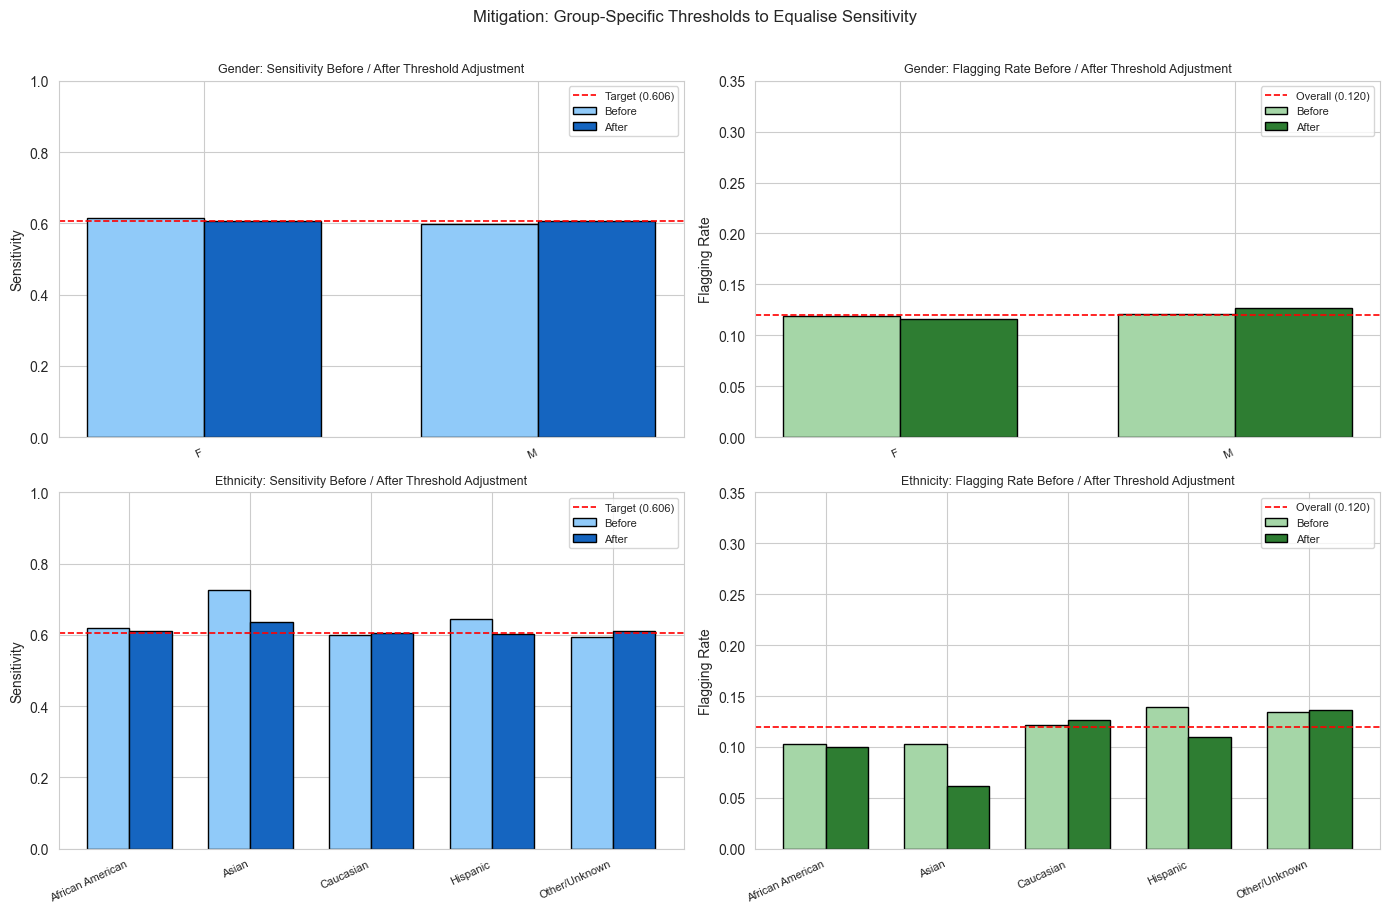

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, (before, after, attr) in enumerate([
        (df_before,     df_after,     'Gender'),
        (df_eth_before, df_eth_after, 'Ethnicity')]):

    x = np.arange(len(before))
    w = 0.35

    # Sensitivity
    ax = axes[row_idx][0]
    ax.bar(x - w/2, before['Sensitivity'], w, label='Before', color='#90CAF9', edgecolor='k')
    ax.bar(x + w/2, after['Sensitivity'],  w, label='After',  color='#1565C0', edgecolor='k')
    ax.axhline(TARGET_SENSITIVITY, color='red', linestyle='--', linewidth=1.2,
               label=f'Target ({TARGET_SENSITIVITY:.3f})')
    ax.set_xticks(x); ax.set_xticklabels(before['Group'], rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{attr}: Sensitivity Before / After Threshold Adjustment', fontsize=9)
    ax.set_ylabel('Sensitivity'); ax.set_ylim(0, 1); ax.legend(fontsize=8)

    # Flagging rate
    ax = axes[row_idx][1]
    ax.bar(x - w/2, before['Flagging Rate'], w, label='Before', color='#A5D6A7', edgecolor='k')
    ax.bar(x + w/2, after['Flagging Rate'],  w, label='After',  color='#2E7D32', edgecolor='k')
    ax.axhline(OVERALL_FLAGGING, color='red', linestyle='--', linewidth=1.2,
               label=f'Overall ({OVERALL_FLAGGING:.3f})')
    ax.set_xticks(x); ax.set_xticklabels(before['Group'], rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{attr}: Flagging Rate Before / After Threshold Adjustment', fontsize=9)
    ax.set_ylabel('Flagging Rate'); ax.set_ylim(0, 0.35); ax.legend(fontsize=8)

plt.suptitle('Mitigation: Group-Specific Thresholds to Equalise Sensitivity',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Mitigation:**

*Gender:* The required adjustment is negligible — female threshold rises from 0.6079 to 0.6132 (flagging 11.9 % → 11.6 %); male threshold falls to 0.5928 (flagging 12.1 % → 12.7 %). After adjustment both groups reach sensitivity ≈ 0.606.

*Ethnicity:*
| Group | Old thresh | Old sens | Old flag | New thresh | New sens | New flag |
|-------|-----------|----------|----------|-----------|----------|----------|
| African American | 0.6079 | 0.619 | 10.3 % | 0.6132 | 0.610 | 10.0 % |
| Caucasian | 0.6079 | 0.600 | 12.2 % | 0.6001 | 0.606 | 12.6 % |
| Hispanic | 0.6079 | 0.646 | 13.9 % | **0.6691** | 0.604 | **11.0 %** |
| Other/Unknown | 0.6079 | 0.593 | 13.4 % | 0.5991 | 0.611 | 13.6 % |

The most consequential change is for **Hispanic patients**: raising the threshold from 0.608 to 0.669 reduces their flagging rate from 13.9 % to 11.0 % — removing an over-triage burden — while still meeting the sensitivity target.
For **Other/Unknown**, a small threshold decrease (0.608 → 0.599) closes the sensitivity gap (0.593 → 0.611) at negligible cost to flagging rate.

> **Ethnicity-specific thresholds yield more clinically meaningful corrections than gender-specific thresholds.** The adjustments are small (< 0.07 threshold units) and require no model retraining.

### 4.1 Multi-Calibration (Barda et al. JAMIA 2021)

Group-specific threshold adjustment equalises sensitivity but does **not** fix
systematic mis-calibration within groups (e.g. the model may consistently
over-estimate risk for Hispanic patients at all probability levels).

**Multi-calibration** (Hébert-Johnson et al. 2018; clinical application: Barda et al. 2021)
enforces that for every subgroup $G$ and every predicted-probability level $v$:

$$\mathbb{E}[Y \mid \hat{p}(X) = v,\; X \in G] = v$$

This is a stronger requirement than group-level calibration — it must hold
simultaneously for *all groups and all risk strata*.
Post-hoc multi-calibration recalibrators (e.g. isotonic regression per group)
can be applied after model training without retraining.

### 4.2 Distributional Justice Frameworks

| Framework | Principle | Implication for this model |
|-----------|-----------|---------------------------|
| **Utilitarianism** | Maximise total lives saved | Use a single threshold that maximises overall sensitivity — may harm small/minority groups |
| **Prioritarianism** | Give extra weight to worst-off | Groups with higher base mortality (e.g. older patients) should have at least equal sensitivity — supports equal-opportunity adjustment |
| **Desert** | Benefit proportional to need | Clinical need (severity) should drive flagging, not demographic membership — supports group-specific thresholds only to *remove* model bias, not to over-privilege |

**Our recommendation:** Adopt equal-opportunity (equal sensitivity) as the primary
fairness criterion, implemented via group-specific thresholds.
This is consistent with prioritarianism and clinical ethics: every patient group
deserves to have their high-risk individuals identified at the same rate.

---
## 5. Summary and Recommendations for Dr. Smith

### What we found

**Gender — no meaningful disparity**
Female and male patients receive near-identical treatment from the model.
ROC-AUC: 0.895 (F) vs 0.887 (M); sensitivity: 0.615 vs 0.598; flagging rate: 11.9 % vs 12.1 %.
The 1.7 pp sensitivity gap is within noise and requires no corrective action.

**Ethnicity — modest gaps; small groups unreliable**
Among groups with enough deaths for reliable estimates:
- **Hispanic** patients are slightly over-flagged (13.9 %) relative to the target 12 %, tracking their higher observed mortality (9.8 %). Sensitivity is 0.646 — above average.
- **Caucasian** patients sit near the population average (sens = 0.600, flag = 12.2 %).
- **African American** patients are under-flagged (10.3 %) but still achieve sensitivity = 0.619.
- **Other/Unknown** has the worst trade-off: lowest sensitivity (0.593) with above-average flagging (13.4 %).

Asian (n = 146, 11 deaths) and Native American (n = 117, 8 deaths) results are statistically unreliable.

**Age group — the most significant fairness concern**
- **45–59 year-olds have the lowest sensitivity (0.525)** — fewer than 1 in 2 middle-aged patients who die is detected. This is a genuine under-service problem.
- **16–44 year-olds have the highest AUC (0.944)** — the model *can* rank young high-risk patients — but only 4.6 % are ever flagged because the global threshold is calibrated to the full population, not to a group with a 4.1 % base rate.
- **75+ patients are flagged at 19.3 %**, correctly reflecting their 12.0 % base mortality. The large flagging-rate gap for the elderly is appropriate, not unfair.

**Intersectional — young African American patients are the most at-risk cell**
The combination of **16–44 age and African American ethnicity** produces sensitivity = 0.385, a 26.8 pp gap vs Caucasian 16–44. Sample size is small (~15 deaths) but the direction is consistent and warrants monitoring.

---

### Mitigation: group-specific thresholds

Deriving group-specific thresholds to equalise sensitivity to the overall target (0.606) requires adjustments of < 0.07 threshold units and no model retraining.

The most impactful change is for **Hispanic patients**: raising the threshold from 0.608 to 0.669 reduces over-flagging (13.9 % → 11.0 %) while preserving recall.
For **Other/Unknown** patients a small decrease (0.608 → 0.599) closes the sensitivity gap from 0.593 to 0.611.
Gender adjustments are negligible.

---

### Limitations

1. **Eval set only (12,382 patients)** — subgroup estimates for small ethnicities carry wide confidence intervals; validate on the held-out test set before any deployment decision.
2. **`hospital_id` unavailable** — removed during preprocessing; hospital-level disparities (staffing, equipment, patient mix) cannot be audited.
3. **Multi-calibration not applied** — threshold adjustment fixes equal-opportunity but not within-group probability mis-calibration. Isotonic recalibration per group is recommended (Barda et al. JAMIA 2021).
4. **Historical bias is encoded** — the training data reflects past clinical decisions (which labs were ordered, who was admitted). If minorities were historically under-tested or under-admitted, the model inherits that bias.
5. **Age demographic-parity gap is partly normative** — the 14.7 pp flagging-rate spread across age groups partly reflects the model correctly recognising higher elderly risk. Imposing strict demographic parity here would harm high-risk elderly patients.

---

### Recommended next steps

1. **Adopt ethnicity-specific thresholds** for Hispanic and Other/Unknown groups and validate on the test set.
2. **Prioritise the 45–59 age band**: investigate age-specific sub-thresholds or additional features to raise sensitivity from 0.525 toward the population average.
3. **Monitor the young × African American intersection** prospectively; collect more data from this cell before deploying in facilities with high proportions of young Black patients.
4. **Implement isotonic recalibration per ethnic group** (multi-calibration) to correct within-group probability bias independently of threshold choices.
5. **Re-audit with hospital_id** if the pipeline is revised: hospital-level stratification may reveal additional disparities driven by facility type or geography.